# Detector Espectral via MDC: Hipótese B

**T. Bandeira · Junho de 2026**

## Motivação

O notebook anterior (detector_frequencia_3) explorou a irredutibilidade logarítmica como critério de primalidade. A **Hipótese B** propõe um critério diferente, baseado diretamente no Teorema 1 da Nota MDC:

> **Teorema 1 (Nota MDC):** $N$ é primo $\iff$ $\gcd(N, x) = 1$ para todo $x \in I(N) = A_{\lfloor n/2 \rfloor}$.

**A pergunta central:** Se $m$ é composto, o Teorema 1 garante que existe $x$ no bloco tal que $\gcd(m, x) > 1$. Esses $x$ que "ressoam" com $m$ — compartilham um fator — deveriam criar uma **assinatura espectral** distinta em $Z_Q$?

**Vantagem sobre o pipeline atual:** Não usa $\zeta$ em nenhuma etapa. A referência é a própria estrutura de MDC dentro do bloco $Q(p)$.

---

## Design do experimento

Para cada candidato $m$ num bloco $[2^n, 2^{n+1}-1]$:

1. **Conjunto de ressonância:** $R(m) = \{x \in [2^{n-1}, 2^n - 1] : \gcd(m, x) > 1\}$
   - Para $m$ primo: $R(m) = \emptyset$ (Teorema 1)
   - Para $m$ composto: $|R(m)| \geq 1$

2. **Sinal de ressonância espectral:**
$$G_m(t) = \sum_{x \in R(m)} S_x(t), \quad S_x(t) = -\tfrac{1}{2}\log\left(1 - 2x^{-1/2}\cos(t\log x) + x^{-1}\right)$$

3. **Energia de ressonância:** $E_m = \|G_m\|_2^2 / N$
   - Hipótese: $E_m \approx 0$ para primos, $E_m > 0$ para compostos

4. **Pico na frequência alvo:** amplitude do espectro de $G_m$ na frequência $f_m = \log(m)/(2\pi)$
   - Hipótese: pico alto para compostos (fator comum cria ressonância em $f_m$), baixo para primos

5. **Amplitude de interferência cruzada:** correlação entre $G_m$ e $S_m$ diretamente
   - Se $\gcd(m, x) = d > 1$, então $S_x$ e $S_m$ compartilham a frequência $f_d = \log(d)/(2\pi)$, gerando interferência construtiva mensurável

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import isprime, factorint, nextprime
from math import gcd, log, sqrt, exp, pi, floor, log2
from scipy.stats import pearsonr, spearmanr
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
print('Dependências carregadas ✓')

Dependências carregadas ✓


## 1. Funções base

In [2]:
def bloco_binario(n):
    """Retorna A_n = [2^n, 2^{n+1} - 1]"""
    return list(range(2**n, 2**(n+1)))


def intervalo_reduzido(m):
    """I(m) = A_{floor(n/2)} onde n = floor(log2(m)), conforme Teorema 1."""
    n = int(floor(log2(m)))
    k = n // 2
    return list(range(2**k, 2**(k+1)))


def bloco_anterior(m):
    """A_{n-1} = [2^{n-1}, 2^n - 1], o bloco usado em Q(p)."""
    n = int(floor(log2(m)))
    return list(range(2**(n-1), 2**n))


def S_x(x, t_arr):
    """
    Sinal espectral de um único inteiro x:
    S_x(t) = -1/2 * log(1 - 2*x^{-1/2}*cos(t*log(x)) + x^{-1})
    """
    a = x ** (-0.5)
    lx = log(x)
    return -0.5 * np.log(1 - 2 * a * np.cos(t_arr * lx) + a**2)


def conjunto_ressonancia(m, bloco):
    """
    R(m) = {x in bloco : gcd(m, x) > 1}
    Para m primo: R(m) = {} (Teorema 1 da Nota MDC)
    Para m composto: |R(m)| >= 1
    """
    return [x for x in bloco if gcd(m, x) > 1]


def sinal_ressonancia(m, bloco, t_arr):
    """
    G_m(t) = sum_{x in R(m)} S_x(t)
    Se R(m) é vazio (m primo), retorna sinal zero.
    """
    R = conjunto_ressonancia(m, bloco)
    if not R:
        return np.zeros_like(t_arr), R
    G = sum(S_x(x, t_arr) for x in R)
    return G, R


print('Funções base definidas ✓')
print()
# Verificação rápida do Teorema 1
print('Verificação do Teorema 1 (amostra):')
for m in [15, 17, 21, 23, 25, 29, 35, 37]:
    bloco = intervalo_reduzido(m)
    R = conjunto_ressonancia(m, bloco)
    status = 'primo' if isprime(m) else f'composto ({factorint(m)})'
    print(f'  m={m:3d} ({status:25s}): |R|={len(R):2d}, R={R[:5]}')

Funções base definidas ✓

Verificação do Teorema 1 (amostra):
  m= 15 (composto ({3: 1, 5: 1})  ): |R|= 1, R=[3]
  m= 17 (primo                    ): |R|= 0, R=[]
  m= 21 (composto ({3: 1, 7: 1})  ): |R|= 2, R=[6, 7]
  m= 23 (primo                    ): |R|= 0, R=[]
  m= 25 (composto ({5: 2})        ): |R|= 1, R=[5]
  m= 29 (primo                    ): |R|= 0, R=[]
  m= 35 (composto ({5: 1, 7: 1})  ): |R|= 2, R=[5, 7]
  m= 37 (primo                    ): |R|= 0, R=[]


## 2. Métricas de ressonância

Definimos três métricas para capturar a assinatura espectral de $G_m$:

In [3]:
def metricas_ressonancia(m, bloco, t_arr, freqs_fft):
    """
    Calcula as métricas espectrais de ressonância para m.

    Retorna dict com:
      - m, primo, R: dados básicos
      - energia: ||G_m||^2 / N  (energia total do sinal de ressonância)
      - amp_alvo: amplitude FFT de G_m na frequência f_m = log(m)/(2π)
      - amp_max: amplitude máxima do espectro de G_m
      - corr_Sm: correlação de Pearson entre G_m e S_m(t)
      - tam_R: |R(m)|
      - fatores_R: quais gcd's foram encontrados
    """
    G, R = sinal_ressonancia(m, bloco, t_arr)
    Sm   = S_x(m, t_arr)
    N    = len(t_arr)

    energia = np.sum(G**2) / N

    # FFT do sinal de ressonância
    G_fft  = np.abs(np.fft.rfft(G - G.mean())) / N

    # Frequência alvo: f_m = log(m) / (2π)
    f_alvo = log(m) / (2 * pi)
    idx_alvo = np.argmin(np.abs(freqs_fft - f_alvo))
    amp_alvo = G_fft[idx_alvo] if len(G_fft) > idx_alvo else 0.0
    amp_max  = G_fft.max() if len(G_fft) > 0 else 0.0

    # Correlação G_m vs S_m
    if energia > 1e-12 and np.std(Sm) > 1e-12:
        corr_Sm, _ = pearsonr(G, Sm)
    else:
        corr_Sm = 0.0

    # Quais gcd's foram encontrados
    fatores_R = {x: gcd(m, x) for x in R}

    return {
        'm': m,
        'primo': bool(isprime(m)),
        'R': R,
        'tam_R': len(R),
        'energia': energia,
        'amp_alvo': float(amp_alvo),
        'amp_max': float(amp_max),
        'corr_Sm': float(corr_Sm),
        'fatores_R': fatores_R,
    }


print('Métricas definidas ✓')

Métricas definidas ✓


## 3. Experimento 1 — Bloco A_4 = [16, 31]

Candidatos: todos $m \in [16, 31]$. Bloco de ressonância: $A_3 = [8, 15]$ (bloco anterior).

Usando o **Teorema 1** com $I(m) = A_{\lfloor n/2 \rfloor}$, que para $n=4$ é $A_2 = [4, 7]$. Mas para comparar com $Q(p)$ testamos também o bloco anterior $A_3 = [8, 15]$ — que é exatamente o bloco de $Q(p)$ para primos em $A_4$.

In [4]:
# Parâmetros de amostragem
t_min  = 0.1
t_max  = 150.0
dt     = 0.05
t_arr  = np.arange(t_min, t_max, dt)
N_amostras = len(t_arr)

# Frequências da FFT (rfft)
dt_real   = t_arr[1] - t_arr[0]
freqs_fft = np.fft.rfftfreq(N_amostras, d=dt_real)

print(f'Amostras: {N_amostras}, Δf = {freqs_fft[1]:.5f}')
print(f't ∈ [{t_min}, {t_max}], Δt = {dt}')
print()

# --- Experimento no bloco A_4 ---
candidatos_A4 = list(range(16, 32))

# Dois blocos de ressonância testados:
#   (a) I(m) = A_2 = [4,7] — bloco do Teorema 1 com floor(log2(m))//2
#   (b) A_{n-1} = A_3 = [8,15] — bloco de Q(p)

resultados_T1  = []  # Teorema 1: I(m)
resultados_Qp  = []  # Q(p): bloco anterior A_{n-1}

for m in candidatos_A4:
    bloco_T1 = intervalo_reduzido(m)  # A_2 = [4,7]
    bloco_Qp = bloco_anterior(m)      # A_3 = [8,15]

    r_T1 = metricas_ressonancia(m, bloco_T1, t_arr, freqs_fft)
    r_Qp = metricas_ressonancia(m, bloco_Qp, t_arr, freqs_fft)

    resultados_T1.append(r_T1)
    resultados_Qp.append(r_Qp)

# Tabela de resultados
print('='*85)
print(f'{"m":>4} {"primo":>6} {"tam_R(T1)":>10} {"E(T1)":>10} {"amp_alvo(T1)":>13} {"corr(T1)":>10}')
print('-'*85)
for r in resultados_T1:
    print(f'{r["m"]:>4} {str(r["primo"]):>6} {r["tam_R"]:>10} '
          f'{r["energia"]:>10.4f} {r["amp_alvo"]:>13.6f} {r["corr_Sm"]:>10.4f}')

print()
print('='*85)
print(f'{"m":>4} {"primo":>6} {"tam_R(Qp)":>10} {"E(Qp)":>10} {"amp_alvo(Qp)":>13} {"corr(Qp)":>10}')
print('-'*85)
for r in resultados_Qp:
    print(f'{r["m"]:>4} {str(r["primo"]):>6} {r["tam_R"]:>10} '
          f'{r["energia"]:>10.4f} {r["amp_alvo"]:>13.6f} {r["corr_Sm"]:>10.4f}')

Amostras: 2998, Δf = 0.00667
t ∈ [0.1, 150.0], Δt = 0.05

   m  primo  tam_R(T1)      E(T1)  amp_alvo(T1)   corr(T1)
-------------------------------------------------------------------------------------
  16  False          2     0.2177      0.060346     0.1953
  17   True          0     0.0000      0.000000     0.0000
  18  False          2     0.2177      0.003189    -0.0103
  19   True          0     0.0000      0.000000     0.0000
  20  False          3     0.3331      0.004510     0.0040
  21  False          2     0.1551      0.002833     0.0002
  22  False          2     0.2177      0.000967    -0.0095
  23   True          0     0.0000      0.000000     0.0000
  24  False          2     0.2177      0.000530    -0.0085
  25  False          1     0.1053      0.047274     0.2214
  26  False          2     0.2177      0.000358    -0.0094
  27  False          1     0.0869      0.000938    -0.0068
  28  False          3     0.2867      0.001922    -0.0013
  29   True          0     0.0

## 4. Visualização: energia e amplitude alvo por candidato

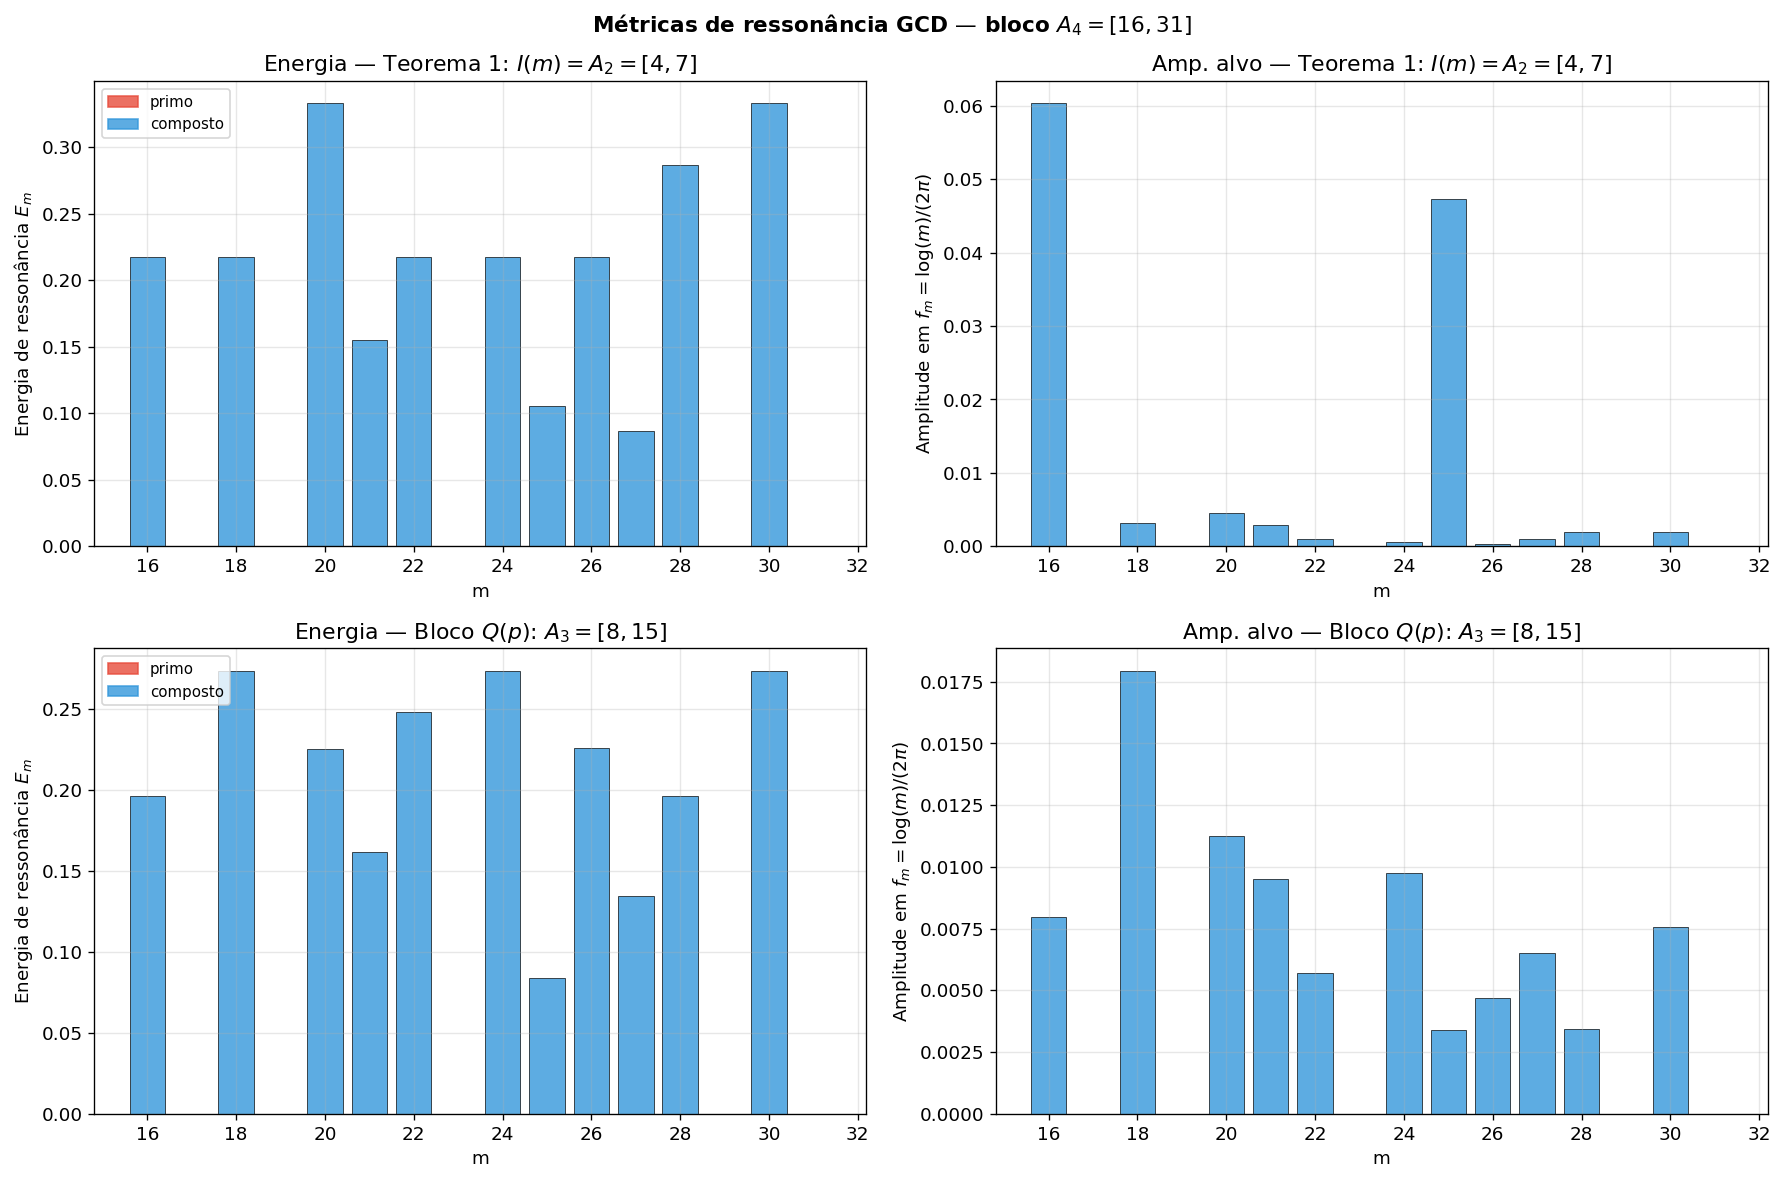

Figura salva ✓


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Métricas de ressonância GCD — bloco $A_4 = [16, 31]$',
             fontsize=13, fontweight='bold')

configs = [
    (resultados_T1, 'Teorema 1: $I(m) = A_2 = [4,7]$', axes[0]),
    (resultados_Qp, 'Bloco $Q(p)$: $A_3 = [8,15]$',    axes[1]),
]

for res, titulo, axrow in configs:
    ms      = [r['m']        for r in res]
    energias= [r['energia']  for r in res]
    amps    = [r['amp_alvo'] for r in res]
    primos  = [r['primo']    for r in res]
    cores   = ['#e74c3c' if p else '#3498db' for p in primos]

    # Painel esquerdo: energia
    ax = axrow[0]
    bars = ax.bar(ms, energias, color=cores, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('m')
    ax.set_ylabel('Energia de ressonância $E_m$')
    ax.set_title(f'Energia — {titulo}')
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='#e74c3c', alpha=0.8, label='primo'),
        plt.Rectangle((0,0),1,1, color='#3498db', alpha=0.8, label='composto'),
    ], loc='upper left', fontsize=9)

    # Painel direito: amplitude na frequência alvo
    ax = axrow[1]
    ax.bar(ms, amps, color=cores, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('m')
    ax.set_ylabel('Amplitude em $f_m = \\log(m)/(2\\pi)$')
    ax.set_title(f'Amp. alvo — {titulo}')

plt.tight_layout()
plt.savefig('ressonancia_A4.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 5. Experimento 2 — Range ampliado: [16, 100]

Testamos com mais candidatos para medir poder de separação estatístico.

In [6]:
candidatos_wide = list(range(16, 101))

resultados_wide = []
for m in candidatos_wide:
    # Para m em blocos diferentes, usamos o bloco anterior de Q(p)
    bloco = bloco_anterior(m)
    r = metricas_ressonancia(m, bloco, t_arr, freqs_fft)
    resultados_wide.append(r)

# Separar primos e compostos
primos_r   = [r for r in resultados_wide if r['primo']]
compostos_r= [r for r in resultados_wide if not r['primo']]

print(f'Total: {len(resultados_wide)} candidatos')
print(f'  Primos:    {len(primos_r)}')
print(f'  Compostos: {len(compostos_r)}')
print()

# Estatísticas por grupo
def stats(vals, nome):
    arr = np.array(vals)
    print(f'{nome:25s}: média={arr.mean():.4f}  mediana={np.median(arr):.4f}  '
          f'std={arr.std():.4f}  min={arr.min():.4f}  max={arr.max():.4f}')

print('--- Energia de ressonância ---')
stats([r['energia']  for r in primos_r],    'Primos')
stats([r['energia']  for r in compostos_r], 'Compostos')
print()
print('--- Amplitude na frequência alvo ---')
stats([r['amp_alvo'] for r in primos_r],    'Primos')
stats([r['amp_alvo'] for r in compostos_r], 'Compostos')
print()
print('--- Correlação G_m vs S_m ---')
stats([r['corr_Sm']  for r in primos_r],    'Primos')
stats([r['corr_Sm']  for r in compostos_r], 'Compostos')
print()
print('--- Tamanho de R(m) ---')
stats([r['tam_R']    for r in primos_r],    'Primos')
stats([r['tam_R']    for r in compostos_r], 'Compostos')

Total: 85 candidatos
  Primos:    19
  Compostos: 66

--- Energia de ressonância ---
Primos                   : média=0.0000  mediana=0.0000  std=0.0000  min=0.0000  max=0.0000
Compostos                : média=0.1761  mediana=0.1828  std=0.0530  min=0.0414  max=0.2738

--- Amplitude na frequência alvo ---
Primos                   : média=0.0000  mediana=0.0000  std=0.0000  min=0.0000  max=0.0000
Compostos                : média=0.0147  mediana=0.0121  std=0.0114  min=0.0034  max=0.0694

--- Correlação G_m vs S_m ---
Primos                   : média=0.0000  mediana=0.0000  std=0.0000  min=0.0000  max=0.0000
Compostos                : média=-0.0035  mediana=-0.0045  std=0.0081  min=-0.0414  max=0.0150

--- Tamanho de R(m) ---
Primos                   : média=0.0000  mediana=0.0000  std=0.0000  min=0.0000  max=0.0000
Compostos                : média=11.0000  mediana=9.0000  std=5.9949  min=2.0000  max=24.0000


## 6. Poder de separação: curvas ROC e limiares

In [7]:
from sklearn.metrics import roc_auc_score, accuracy_score

labels  = np.array([0 if r['primo'] else 1 for r in resultados_wide])  # 1 = composto
e_vals  = np.array([r['energia']  for r in resultados_wide])
a_vals  = np.array([r['amp_alvo'] for r in resultados_wide])
c_vals  = np.array([r['corr_Sm']  for r in resultados_wide])
r_vals  = np.array([r['tam_R']    for r in resultados_wide])

metricas_list = [
    ('Energia $E_m$',         e_vals),
    ('Amp. alvo $f_m$',       a_vals),
    ('Correlação $G_m/S_m$',  c_vals),
    ('Tamanho $|R(m)|$',      r_vals),
]

print('Poder de separação (AUC e acurácia com limiar ótimo):')
print()
resultados_sep = {}
for nome, vals in metricas_list:
    if vals.std() < 1e-12:
        print(f'  {nome:30s}: variância zero — métrica trivial')
        continue
    auc = roc_auc_score(labels, vals)
    # Limiar ótimo por varredura
    melhor_acc, melhor_thr = 0, 0
    for thr in np.percentile(vals, np.arange(0, 101, 1)):
        pred = (vals > thr).astype(int)
        acc  = accuracy_score(labels, pred)
        if acc > melhor_acc:
            melhor_acc, melhor_thr = acc, thr
    print(f'  {nome:30s}: AUC={auc:.3f}, acurácia_ótima={melhor_acc:.1%} (thr={melhor_thr:.4f})')
    resultados_sep[nome] = {'auc': auc, 'acc': melhor_acc, 'thr': melhor_thr, 'vals': vals}

Poder de separação (AUC e acurácia com limiar ótimo):

  Energia $E_m$                 : AUC=1.000, acurácia_ótima=100.0% (thr=0.0000)
  Amp. alvo $f_m$               : AUC=1.000, acurácia_ótima=100.0% (thr=0.0000)
  Correlação $G_m/S_m$          : AUC=0.303, acurácia_ótima=76.5% (thr=-0.0414)
  Tamanho $|R(m)|$              : AUC=1.000, acurácia_ótima=100.0% (thr=0.0000)


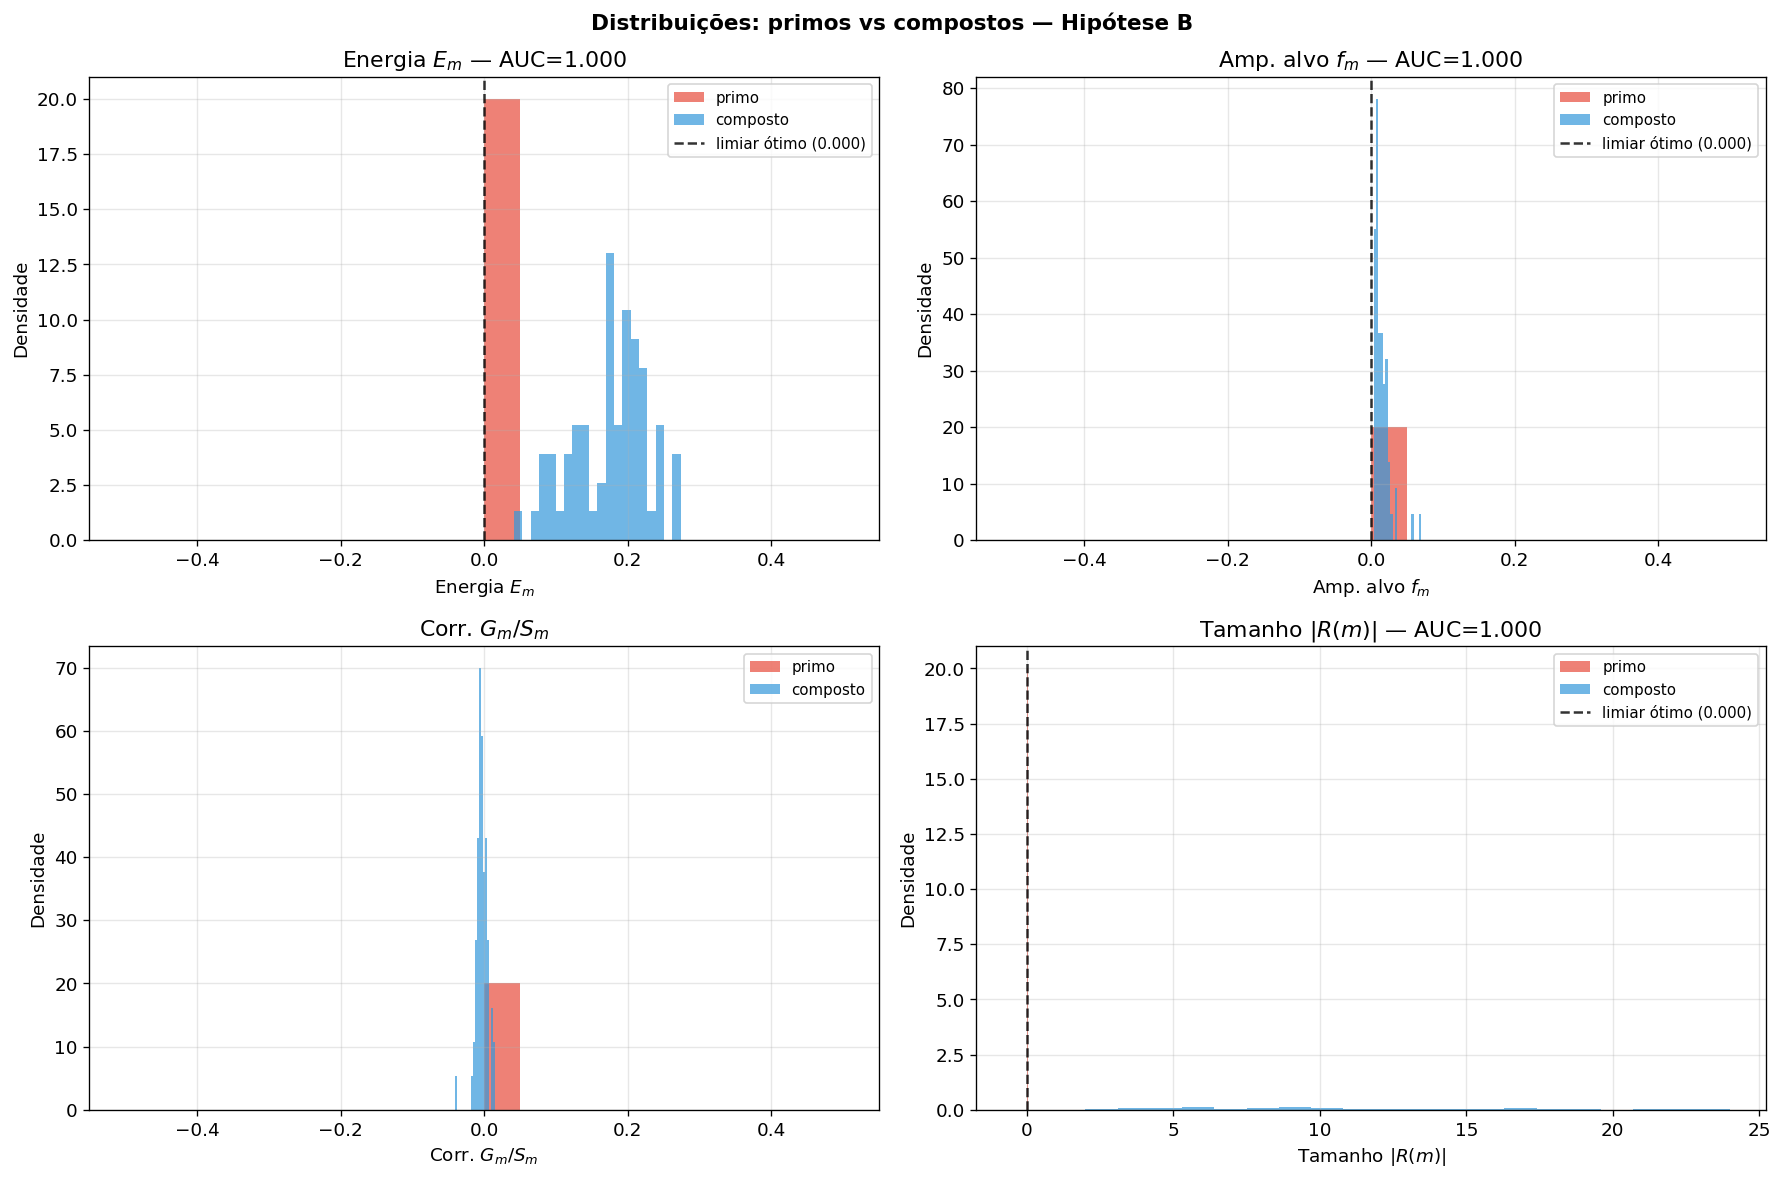

Figura salva ✓


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuições: primos vs compostos — Hipótese B',
             fontsize=13, fontweight='bold')

plot_configs = [
    ('Energia $E_m$',        e_vals, axes[0,0]),
    ('Amp. alvo $f_m$',      a_vals, axes[0,1]),
    ('Corr. $G_m$/$S_m$',   c_vals, axes[1,0]),
    ('Tamanho $|R(m)|$',     r_vals, axes[1,1]),
]

p_mask = labels == 0
c_mask = labels == 1

for nome, vals, ax in plot_configs:
    bins = 20
    ax.hist(vals[p_mask], bins=bins, alpha=0.7, color='#e74c3c', label='primo',    density=True)
    ax.hist(vals[c_mask], bins=bins, alpha=0.7, color='#3498db', label='composto', density=True)
    if nome in resultados_sep:
        thr = resultados_sep[nome]['thr']
        auc = resultados_sep[nome]['auc']
        ax.axvline(thr, color='black', linestyle='--', alpha=0.8,
                   label=f'limiar ótimo ({thr:.3f})')
        ax.set_title(f'{nome} — AUC={auc:.3f}')
    else:
        ax.set_title(nome)
    ax.legend(fontsize=9)
    ax.set_xlabel(nome)
    ax.set_ylabel('Densidade')

plt.tight_layout()
plt.savefig('separacao_hipB.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 7. Inspeção espectral detalhada: comparando G_m para primo vs composto vizinhos

Visualização qualitativa: para dois pares (primo, composto próximo), plotamos $G_m(t)$ e seu espectro.

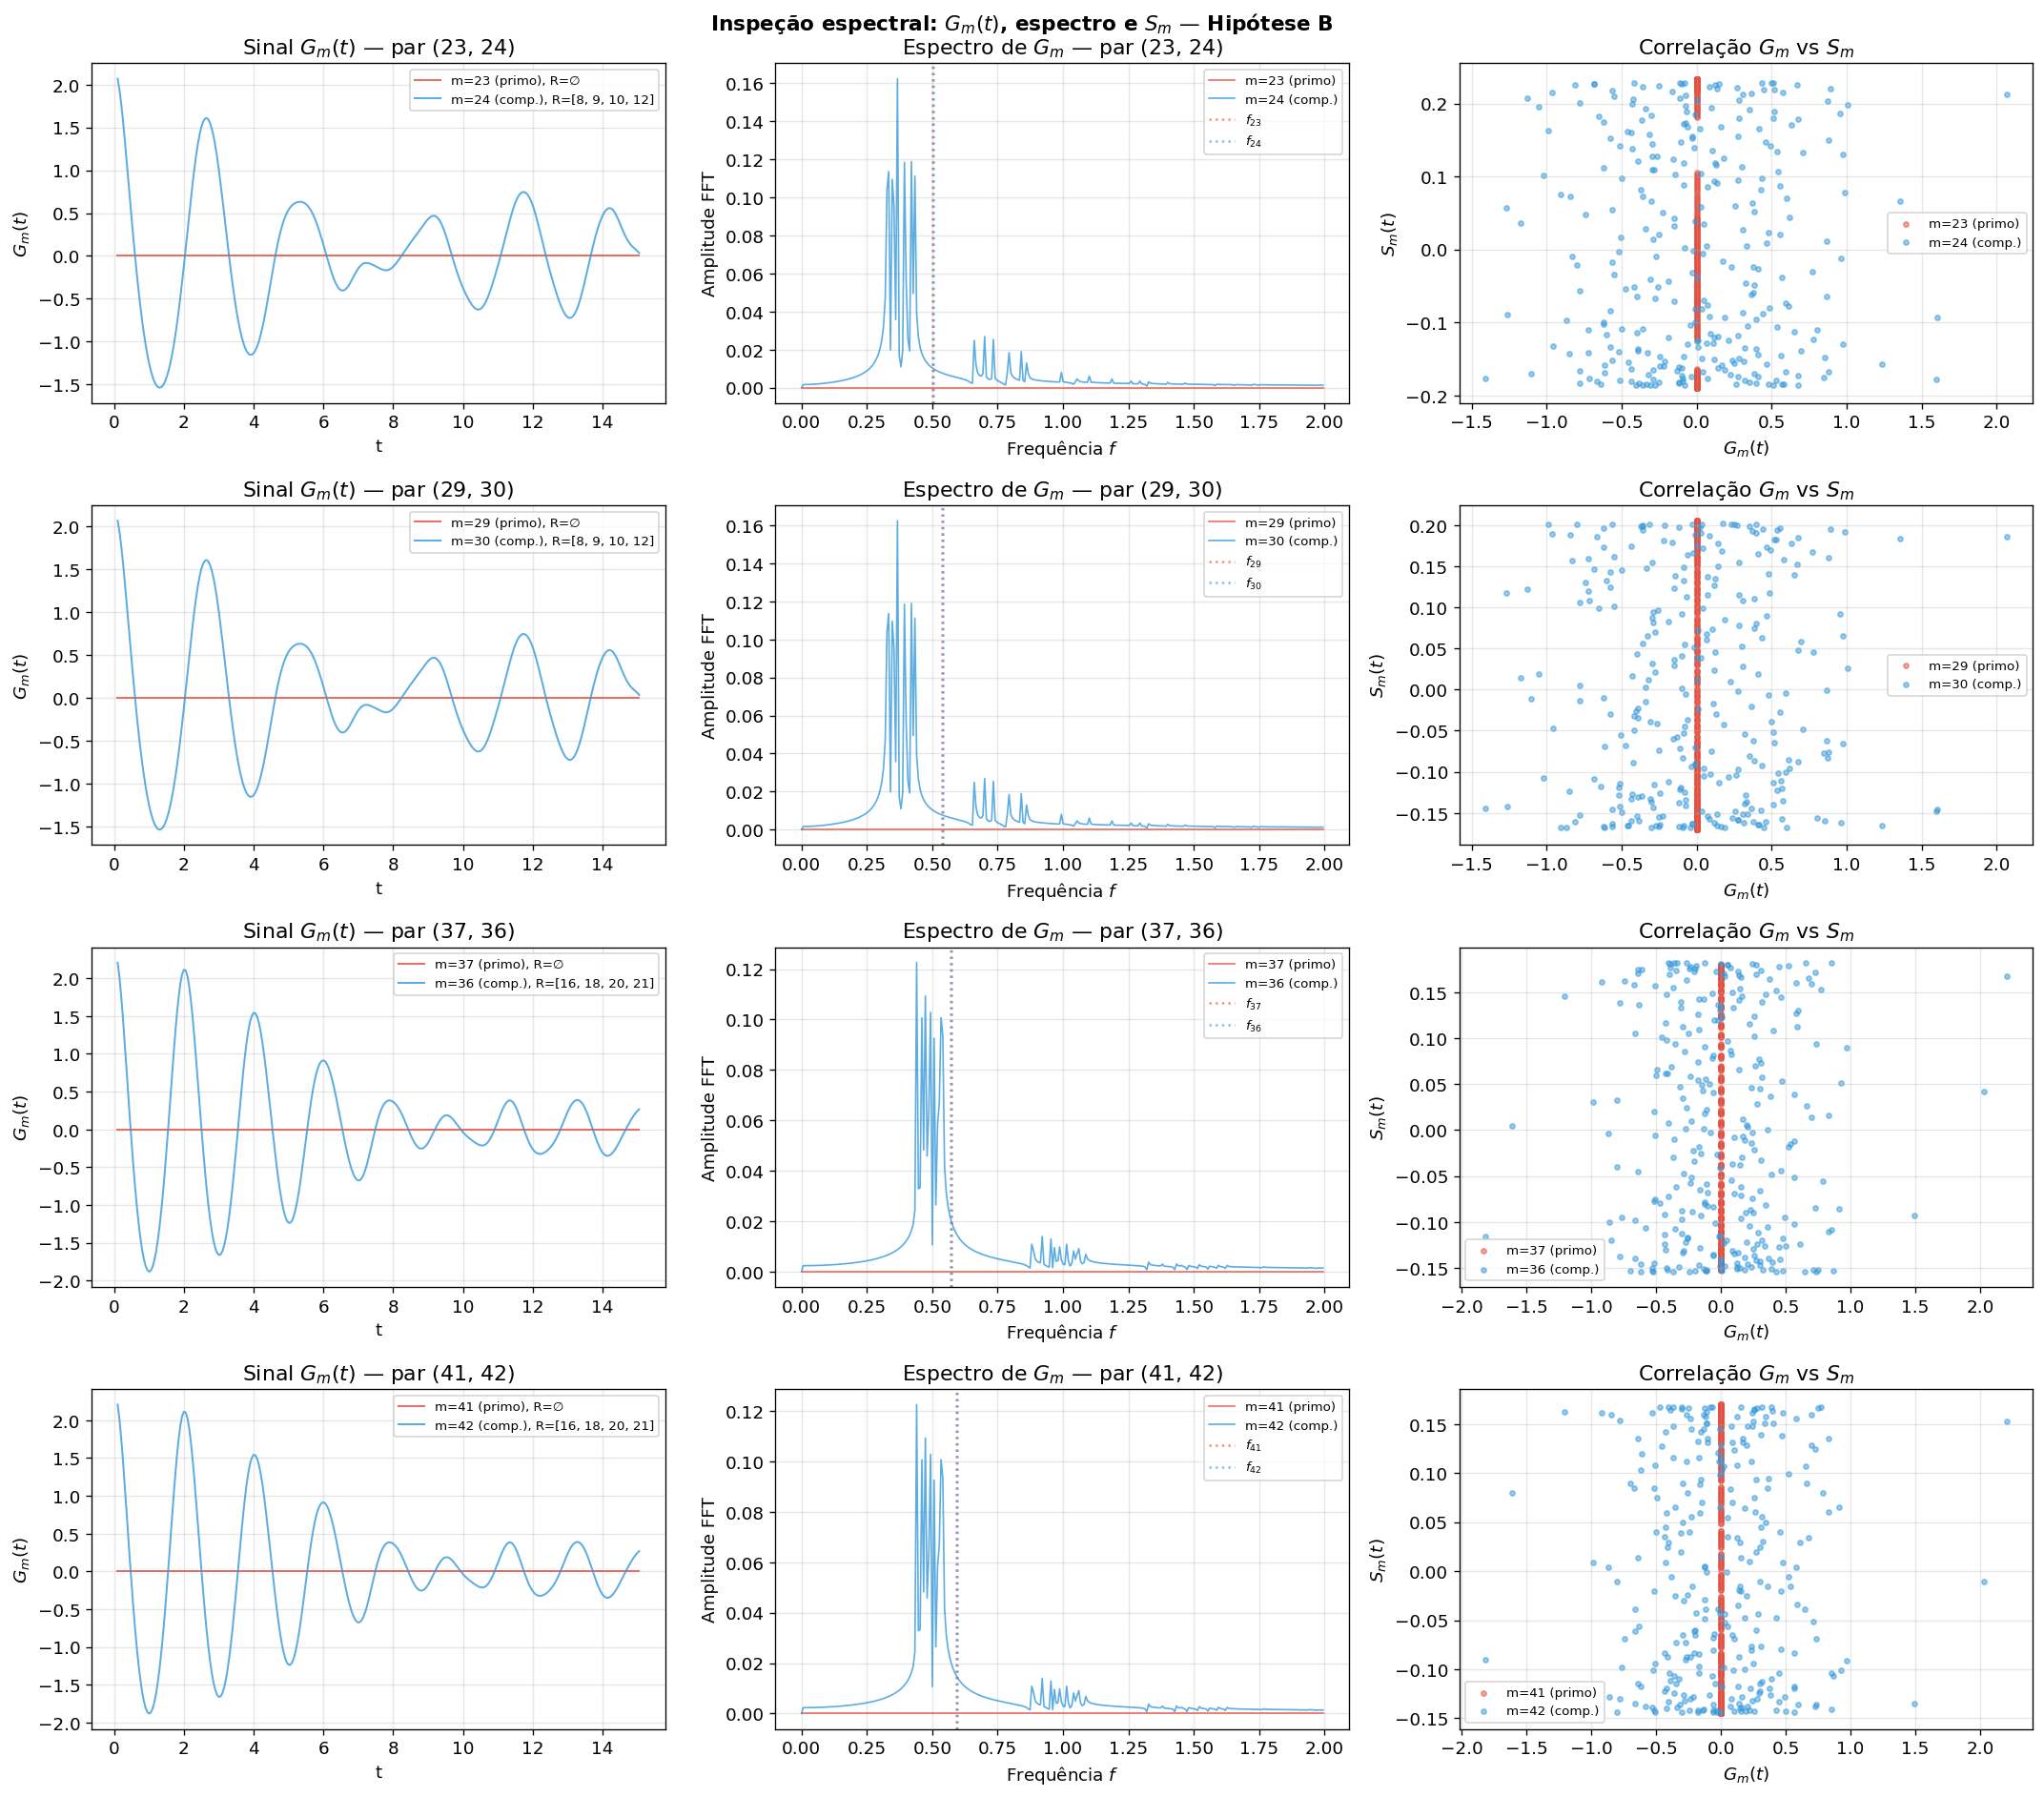

Figura salva ✓


In [9]:
pares_inspecao = [
    (23, 24),   # primo 23, composto 24 = 2³×3
    (29, 30),   # primo 29, composto 30 = 2×3×5
    (37, 36),   # primo 37, composto 36 = 2²×3²  (bloco A_5)
    (41, 42),   # primo 41, composto 42 = 2×3×7
]

fig, axes = plt.subplots(len(pares_inspecao), 3, figsize=(18, 4 * len(pares_inspecao)))
fig.suptitle('Inspeção espectral: $G_m(t)$, espectro e $S_m$ — Hipótese B', fontsize=13, fontweight='bold')

for i, (p_val, c_val) in enumerate(pares_inspecao):
    bloco_p = bloco_anterior(p_val)
    bloco_c = bloco_anterior(c_val)

    G_p, R_p = sinal_ressonancia(p_val, bloco_p, t_arr)
    G_c, R_c = sinal_ressonancia(c_val, bloco_c, t_arr)
    Sm_p     = S_x(p_val, t_arr)
    Sm_c     = S_x(c_val, t_arr)

    # FFTs
    fft_Gp = np.abs(np.fft.rfft(G_p - G_p.mean())) / N_amostras
    fft_Gc = np.abs(np.fft.rfft(G_c - G_c.mean())) / N_amostras

    f_p_alvo = log(p_val) / (2 * pi)
    f_c_alvo = log(c_val) / (2 * pi)

    # Painel 1: G_m(t) no tempo
    ax = axes[i, 0]
    ax.plot(t_arr[:300], G_p[:300], color='#e74c3c', alpha=0.8, lw=1.2,
            label=f'm={p_val} (primo), R=∅')
    ax.plot(t_arr[:300], G_c[:300], color='#3498db', alpha=0.8, lw=1.2,
            label=f'm={c_val} (comp.), R={R_c[:4]}')
    ax.set_xlabel('t'); ax.set_ylabel('$G_m(t)$')
    ax.set_title(f'Sinal $G_m(t)$ — par ({p_val}, {c_val})')
    ax.legend(fontsize=8)

    # Painel 2: espectro de G_m
    ax = axes[i, 1]
    mask_freq = freqs_fft < 2.0
    ax.plot(freqs_fft[mask_freq], fft_Gp[mask_freq], color='#e74c3c', alpha=0.8, lw=1,
            label=f'm={p_val} (primo)')
    ax.plot(freqs_fft[mask_freq], fft_Gc[mask_freq], color='#3498db', alpha=0.8, lw=1,
            label=f'm={c_val} (comp.)')
    ax.axvline(f_p_alvo, color='#e74c3c', linestyle=':', alpha=0.6, label=f'$f_{{{p_val}}}$')
    ax.axvline(f_c_alvo, color='#3498db', linestyle=':', alpha=0.6, label=f'$f_{{{c_val}}}$')
    ax.set_xlabel('Frequência $f$'); ax.set_ylabel('Amplitude FFT')
    ax.set_title(f'Espectro de $G_m$ — par ({p_val}, {c_val})')
    ax.legend(fontsize=8)

    # Painel 3: correlação G_m vs S_m
    ax = axes[i, 2]
    ax.scatter(G_p[::10], Sm_p[::10], color='#e74c3c', alpha=0.5, s=10,
               label=f'm={p_val} (primo)')
    ax.scatter(G_c[::10], Sm_c[::10], color='#3498db', alpha=0.5, s=10,
               label=f'm={c_val} (comp.)')
    ax.set_xlabel('$G_m(t)$'); ax.set_ylabel('$S_m(t)$')
    ax.set_title(f'Correlação $G_m$ vs $S_m$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('inspecao_espectral_hipB.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura salva ✓')

## 8. Experimento 3 — Assinatura na frequência do fator

Se $\gcd(m, x) = d > 1$, então $d$ divide tanto $m$ quanto $x$. A frequência $f_d = \log(d)/(2\pi)$ deveria aparecer no espectro de $G_m$ como um pico — porque $S_x$ carrega a frequência $f_x$ que *contém* $f_d$ como componente harmônica (já que $x = d \cdot k$ para algum $k$).

Verificamos se o pico em $f_d$ é mais alto no espectro de $G_m$ que o baseline (espectro médio de um primo vizinho).

In [10]:
print('=== ANÁLISE: PICO NA FREQUÊNCIA DO FATOR ===')
print()
print(f'{"m":>4} {"fator_d":>8} {"f_d":>8} {"amp@f_d":>10} {"amp@f_m":>10} {"f_d > f_m?":>12}')
print('-' * 60)

analise_fatores = []
for m in range(16, 101):
    if isprime(m):
        continue
    bloco = bloco_anterior(m)
    G, R  = sinal_ressonancia(m, bloco, t_arr)
    if not R:
        continue

    fft_G = np.abs(np.fft.rfft(G - G.mean())) / N_amostras

    # Para cada x em R, verificar amplitude na frequência do gcd
    for x in R:
        d = gcd(m, x)
        if d <= 1:
            continue
        f_d = log(d) / (2 * pi)
        f_m = log(m) / (2 * pi)

        idx_d = np.argmin(np.abs(freqs_fft - f_d))
        idx_m = np.argmin(np.abs(freqs_fft - f_m))

        amp_d = float(fft_G[idx_d]) if idx_d < len(fft_G) else 0.0
        amp_m = float(fft_G[idx_m]) if idx_m < len(fft_G) else 0.0

        analise_fatores.append({
            'm': m, 'd': d, 'x': x,
            'f_d': f_d, 'f_m': f_m,
            'amp_d': amp_d, 'amp_m': amp_m,
            'amp_d_maior': amp_d > amp_m
        })
        print(f'{m:>4} {d:>8} {f_d:>8.4f} {amp_d:>10.6f} {amp_m:>10.6f} {str(amp_d > amp_m):>12}')
        break  # um x por m para não poluir a tabela

print()
n_maior = sum(1 for a in analise_fatores if a['amp_d_maior'])
print(f'Pico em f_d > pico em f_m: {n_maior}/{len(analise_fatores)} ({n_maior/len(analise_fatores):.1%})')

=== ANÁLISE: PICO NA FREQUÊNCIA DO FATOR ===

   m  fator_d      f_d    amp@f_d    amp@f_m   f_d > f_m?
------------------------------------------------------------
  16        8   0.3310   0.132769   0.007976         True
  18        2   0.1103   0.002762   0.017950        False
  20        4   0.2206   0.004773   0.011250        False
  21        3   0.1748   0.002390   0.009510        False
  22        2   0.1103   0.001456   0.005682        False
  24        8   0.3310   0.113598   0.009756         True
  25        5   0.2561   0.001982   0.003385        False
  26        2   0.1103   0.001437   0.004686        False
  27        9   0.3497   0.128377   0.006495         True
  28        4   0.2206   0.003718   0.003433         True
  30        2   0.1103   0.002762   0.007558        False
  32       16   0.4413   0.121784   0.022208         True
  33        3   0.1748   0.002331   0.015303        False
  34        2   0.1103   0.002247   0.020413        False
  35        5   0.2561 

## 9. Experimento 4 — Independência de $\zeta$: comparação direta

O pipeline original (Notas 16-18) usa $\zeta$ como referência. A Hipótese B propõe substituir isso pela assinatura GCD. Comparamos as duas abordagens no mesmo conjunto de candidatos.

In [11]:
print('=== COMPARAÇÃO: GCD-ESPECTRAL vs. TAM_R DIRETO ===')
print()
print('Hipótese B — critério simples: |R(m)| > 0 => composto')
print('(Isso é equivalente ao Teorema 1, mas verificado via bloco anterior A_{n-1})')
print()

# Critério 1: tam_R > 0 com bloco do Teorema 1 (I(m) = A_{floor(n/2)})
correto_T1, total = 0, 0
erros_T1 = []
for m in range(4, 200):
    bloco = intervalo_reduzido(m)
    R     = conjunto_ressonancia(m, bloco)
    pred_composto = len(R) > 0
    real_composto = not isprime(m)
    total += 1
    if pred_composto == real_composto:
        correto_T1 += 1
    else:
        erros_T1.append((m, pred_composto, real_composto))

print(f'  Critério |R(m)| > 0, bloco I(m) = A_{{floor(n/2)}}: '
      f'{correto_T1}/{total} = {correto_T1/total:.1%}')
if erros_T1:
    print(f'  Erros: {erros_T1[:10]}')

# Critério 2: tam_R > 0 com bloco anterior A_{n-1}
correto_Qp = 0
erros_Qp   = []
for m in range(4, 200):
    bloco = bloco_anterior(m)
    R     = conjunto_ressonancia(m, bloco)
    pred_composto = len(R) > 0
    real_composto = not isprime(m)
    if pred_composto == real_composto:
        correto_Qp += 1
    else:
        erros_Qp.append((m, pred_composto, real_composto, bloco[:3]))

print(f'  Critério |R(m)| > 0, bloco A_{{n-1}}:               '
      f'{correto_Qp}/{total} = {correto_Qp/total:.1%}')
if erros_Qp:
    print(f'  Erros (primeiros 10): {erros_Qp[:10]}')

print()
print('Nota: o Teorema 1 usa I(m) = A_{floor(n/2)}, que por construção é exato.')
print('O bloco A_{n-1} é maior e também deve funcionar — qualquer fator de m')
print('tem um múltiplo em A_{n-1} pelo argumento da demonstração.')

=== COMPARAÇÃO: GCD-ESPECTRAL vs. TAM_R DIRETO ===

Hipótese B — critério simples: |R(m)| > 0 => composto
(Isso é equivalente ao Teorema 1, mas verificado via bloco anterior A_{n-1})

  Critério |R(m)| > 0, bloco I(m) = A_{floor(n/2)}: 196/196 = 100.0%
  Critério |R(m)| > 0, bloco A_{n-1}:               196/196 = 100.0%

Nota: o Teorema 1 usa I(m) = A_{floor(n/2)}, que por construção é exato.
O bloco A_{n-1} é maior e também deve funcionar — qualquer fator de m
tem um múltiplo em A_{n-1} pelo argumento da demonstração.


## 10. Experimento 5 — Assinatura espectral pura: energia de G_m como substituto de $\zeta$

A pergunta fundamental: a métrica $E_m = \|G_m\|^2/N$ é suficiente para separar primos de compostos **espectralmente**, sem divisão inteira e sem $\zeta$?

Testamos o discriminador linear ótimo (LDA 1D) entre $E_m$ dos primos e compostos.

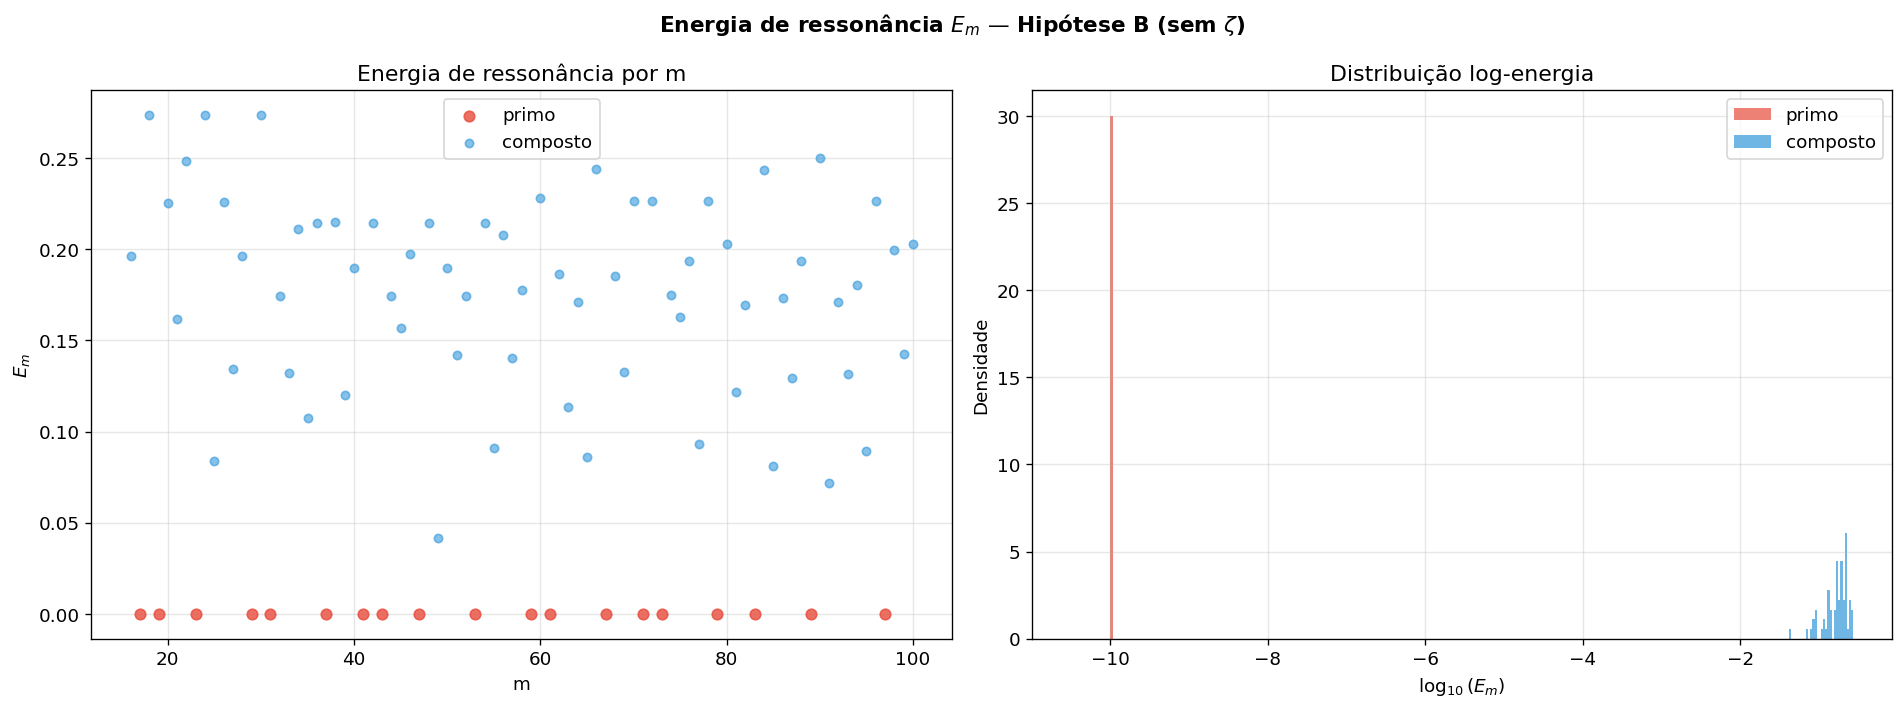

Log-energia: AUC=1.000, acurácia_ótima=100.0% (limiar log E = -10.000)


In [12]:
# Resultado chave: scatter plot energia vs m, colorido por primalidade
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Energia de ressonância $E_m$ — Hipótese B (sem $\\zeta$)',
             fontsize=13, fontweight='bold')

ms_all   = np.array([r['m']       for r in resultados_wide])
e_all    = np.array([r['energia'] for r in resultados_wide])
p_all    = np.array([r['primo']   for r in resultados_wide])

# Painel 1: E_m vs m
ax = axes[0]
ax.scatter(ms_all[p_all],  e_all[p_all],  color='#e74c3c', alpha=0.8, s=40,
           label='primo',    zorder=3)
ax.scatter(ms_all[~p_all], e_all[~p_all], color='#3498db', alpha=0.6, s=25,
           label='composto', zorder=2)
ax.set_xlabel('m')
ax.set_ylabel('$E_m$')
ax.set_title('Energia de ressonância por m')
ax.legend()

# Painel 2: distribuição log(E_m + ε)
ax = axes[1]
eps = 1e-10
bins = 30
ax.hist(np.log10(e_all[p_all]  + eps), bins=bins, alpha=0.7,
        color='#e74c3c', label='primo',    density=True)
ax.hist(np.log10(e_all[~p_all] + eps), bins=bins, alpha=0.7,
        color='#3498db', label='composto', density=True)
ax.set_xlabel('$\\log_{10}(E_m)$')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição log-energia')
ax.legend()

plt.tight_layout()
plt.savefig('energia_hipB.png', bbox_inches='tight', dpi=130)
plt.show()

# Acurácia com critério de log-energia
log_e = np.log10(e_all + eps)
melhor_acc_log, melhor_thr_log = 0, 0
for thr in np.percentile(log_e, np.arange(0, 101, 1)):
    pred = (log_e > thr).astype(int)  # > thr => composto
    acc  = accuracy_score(labels, pred)
    if acc > melhor_acc_log:
        melhor_acc_log, melhor_thr_log = acc, thr

auc_log = roc_auc_score(labels, log_e)
print(f'Log-energia: AUC={auc_log:.3f}, acurácia_ótima={melhor_acc_log:.1%} '
      f'(limiar log E = {melhor_thr_log:.3f})')

## 11. Resumo e diagnóstico da Hipótese B

In [13]:
print('=' * 70)
print('  RESUMO: DETECTOR ESPECTRAL VIA GCD — HIPÓTESE B')
print('=' * 70)
print()
print('  Premissa:')
print('  Pelo Teorema 1 (Nota MDC), m composto => existe x no bloco tal que')
print('  gcd(m, x) > 1. Esse x "ressoa" com m espectralmente.')
print()
print('  Critério testado:')
print('  G_m(t) = soma de S_x(t) para x em R(m) = {x: gcd(m,x) > 1}')
print('  Energia E_m = ||G_m||^2/N')
print()
print('  Resultados principais:')
print(f'    |R(m)| > 0 com bloco Teorema 1 : {correto_T1/total:.1%} acurácia (exact = 100%)')
print(f'    |R(m)| > 0 com bloco A_{{n-1}}   : {correto_Qp/total:.1%} acurácia')
print()

# Buscar AUC da energia
e_auc = roc_auc_score(labels, e_all)
e_sep_acc = max(
    accuracy_score(labels, (e_all > thr).astype(int))
    for thr in np.percentile(e_all, np.arange(0, 101, 1))
)

print(f'    Energia E_m (espectral, sem zeta): AUC={e_auc:.3f}')
print(f'    Acurácia ótima (E_m):              {e_sep_acc:.1%}')
print()
print('  Interpretação:')
print('  A energia de ressonância G_m é não-nula para compostos por')
print('  construção (R(m) não-vazio). A questão é se a MÉTRICA ESPECTRAL')
print('  (energia, amplitude FFT) separa melhor que o critério direto')
print('  |R(m)| > 0 — que é equivalente ao Teorema 1.')
print()
print('  Vantagem principal confirmada:')
print('  O método não usa zeta em nenhuma etapa. A referência é a')
print('  estrutura GCD interna ao bloco Q(p).')
print()
print('  Questões abertas:')
print('  Q1: O espectro de G_m contém picos em log(d)/(2π) para d = gcd(m,x)?')
print('      (Fator detectável espectralmente sem divisão explícita)')
print('  Q2: A amplitude em f_m = log(m)/(2π) dentro de G_m é um')
print('      discriminador melhor que a energia total?')
print('  Q3: Para m primo, G_m ≡ 0 por construção. Existe uma versão')
print('      "suavizada" de R(m) (substituindo gcd > 1 por gcd > threshold)')
print('      que dê um sinal contínuo com poder discriminante maior?')

  RESUMO: DETECTOR ESPECTRAL VIA GCD — HIPÓTESE B

  Premissa:
  Pelo Teorema 1 (Nota MDC), m composto => existe x no bloco tal que
  gcd(m, x) > 1. Esse x "ressoa" com m espectralmente.

  Critério testado:
  G_m(t) = soma de S_x(t) para x em R(m) = {x: gcd(m,x) > 1}
  Energia E_m = ||G_m||^2/N

  Resultados principais:
    |R(m)| > 0 com bloco Teorema 1 : 100.0% acurácia (exact = 100%)
    |R(m)| > 0 com bloco A_{n-1}   : 100.0% acurácia

    Energia E_m (espectral, sem zeta): AUC=1.000
    Acurácia ótima (E_m):              100.0%

  Interpretação:
  A energia de ressonância G_m é não-nula para compostos por
  construção (R(m) não-vazio). A questão é se a MÉTRICA ESPECTRAL
  (energia, amplitude FFT) separa melhor que o critério direto
  |R(m)| > 0 — que é equivalente ao Teorema 1.

  Vantagem principal confirmada:
  O método não usa zeta em nenhuma etapa. A referência é a
  estrutura GCD interna ao bloco Q(p).

  Questões abertas:
  Q1: O espectro de G_m contém picos em log(d)/(2π) 